# 03_mining_v1 — Spearman·t-test·OLS baseline + cheap-talk 통제 (풀 사이클 v1)

> **작성자**: 이동원 · **작성일**: 2026-05-18 · **버전**: v1 (신설)
> **입력**: `members/이동원/notebooks/02_preprocessing/02_preprocessing_v2.ipynb` 산출 `esg_features_v2.parquet`
> **산출**: `data/processed/regression_results_v1.csv` + `fig_v1_mining_*.png`
> **진단 보고서**: `members/이동원/reports/01_collection/03_phase2A_diagnosis_10steps_v1.html` Step 10

---

## 📚 본 노트북의 위치

phase2A 진단 Step 10: 03_mining 폴더에 .gitkeep만 있었음. 풀 사이클 v1 완주를 위해 신설. **N=1 (Samsung 1건)이라 회귀 변동성은 0**이지만 (a) 코드/표/시각화 형식 (b) Spearman·t-test·OLS·specificity 4종 검증 (c) 가이드 03 line 220-274 모형 선택 근거 보고서 형식을 완성. v3 batch 후 동일 노트북 재실행으로 정상 통계 자동 확보.

## 🛡️ 가이드 03·04 매핑

| 가이드 항목 | 본 v1 구현 |
|---|---|
| 03 line 159-197 (Spearman 검증) | Step 2 — N=1이라 NaN 출력, 코드 검증 OK |
| 03 line 220-274 (OLS·ordered·binary logit) | Step 3 — OLS baseline + word_count + specificity |
| 03 line 232-234 (cheap-talk 통제) | word_count + (alpha) specificity score |
| 04 §3 평가표 모형 선택 | Step 4 — 본 v1은 OLS만, ordered_logit·binary 코드는 v2 안내 |
| 04 §3-1 알파 분석 | Step 5 — specificity score 추가 통제 = α1 |

## 🗺️ Step

| Step | What |
|---|---|
| 1 | esg_features_v2 + kcgs_lineage 로드 + 검증 |
| 2 | Spearman + t-test + Mann-Whitney (N=1 NaN) |
| 3 | OLS baseline — esg_grade_num ~ seed_tfidf_X + word_count |
| 4 | 모형 선택 근거 보고서 형식 (OLS·ordered·binary 비교 표) |
| 5 | alpha 분석 — specificity score 추가 통제 (벤치마킹 4번) |
| 6 | self-check + v3 batch 후 재실행 안내 |


---
## Step 1 — esg_features + kcgs_lineage 로드 + 검증

### What
02_preprocessing_v2 산출 esg_features_v2.parquet 로드 → kcgs_lineage join (00_ingest 산출) → N 확인.

### Why
풀 사이클 v1은 N=1이지만 가이드 04 §2-1 재현성 체크 위해 명시 출력.


In [1]:
import os
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def find_project_root(start=None):
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'data' / 'company_master.csv').exists():
            return parent
    raise RuntimeError('루트를 찾지 못함')

ROOT = find_project_root()
print(f'📍 ROOT: {ROOT}')

# 한국어 폰트
try:
    plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'NanumGothic']
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

# 입력 로딩
features_path = ROOT / 'data' / 'processed' / 'esg_features_v2.parquet'
assert features_path.exists(), f'❌ {features_path.name} 없음 — 02_preprocessing_v2 먼저 실행'
features = pd.read_parquet(features_path)
print(f'📊 esg_features_v2: {len(features)}행 × {len(features.columns)}컬럼')
display(features)

N = len(features)
print(f'\n⚠️ N = {N}')
if N < 5:
    print(f'   회귀·Spearman·t-test 모두 통계 의미 없음 — 코드 형식 검증용')
    print(f'   v3 batch (N≥30) 후 동일 노트북 재실행 → 정상 통계 자동 산출')

📍 ROOT: C:\Users\kik32\workspace\unstructured-data-processing-final-project
📊 esg_features_v2: 1행 × 20컬럼


,stock_code,fiscal_year,seed_tfidf_E,seed_tfidf_S,seed_tfidf_G,cosine_E,cosine_S,cosine_G,n_tokens,doc_char_count,word_count,esg_year,esg_grade,esg_grade_num,e_grade,s_grade,g_grade,e_grade_num,s_grade_num,g_grade_num
0,005930,2024,0.051084,0.010479,0.3589,0.036897,0.039908,0.168445,12159,90739,12159,2025,A,4,B+,A+,B+,3,5,3



⚠️ N = 1
   회귀·Spearman·t-test 모두 통계 의미 없음 — 코드 형식 검증용
   v3 batch (N≥30) 후 동일 노트북 재실행 → 정상 통계 자동 산출


---
## Step 2 — Spearman 순위상관 + t-test + Mann-Whitney (가이드 03 line 159-197)

### What
seed_tfidf_X ↔ esg_grade_num·X_grade_num 차원별 Spearman ρ + p-value 계산. 상위 vs 하위 등급 t-test 추가.

### Why
- 가이드 03 line 159-179: Spearman 우선 (등급은 ordinal)
- 가이드 03 line 190-192: t-test 또는 Mann-Whitney 추가
- 가이드 04 §3 평가표 "측정 validity"

### 근거
- ρ ≥ 0.10 & p < 0.05 → 약한 연관성
- N=1이라 NaN 출력 (코드 검증 OK)


In [2]:
# Spearman + t-test 검증 함수
def feature_validity(features_df, score_col, grade_col):
    """단일 feature의 grade 연관성 검증 (Spearman + t-test).

    Returns: {'spearman_rho', 'spearman_p', 'high_mean', 'low_mean',
              't_stat', 't_p', 'mw_stat', 'mw_p', 'n'}
    """
    df = features_df.dropna(subset=[score_col, grade_col]).copy()
    n = len(df)
    if n < 3:
        return {'spearman_rho': np.nan, 'spearman_p': np.nan,
                'high_mean': np.nan, 'low_mean': np.nan,
                't_stat': np.nan, 't_p': np.nan, 'mw_stat': np.nan, 'mw_p': np.nan, 'n': n}
    rho, p = stats.spearmanr(df[score_col], df[grade_col])
    # 상위/하위 split (median)
    med = df[grade_col].median()
    high = df[df[grade_col] >= med][score_col]
    low = df[df[grade_col] < med][score_col]
    if len(high) < 2 or len(low) < 2:
        t_stat = t_p = mw_stat = mw_p = np.nan
    else:
        t_stat, t_p = stats.ttest_ind(high, low, equal_var=False)
        mw_stat, mw_p = stats.mannwhitneyu(high, low, alternative='two-sided')
    return {
        'spearman_rho': rho, 'spearman_p': p,
        'high_mean': high.mean(), 'low_mean': low.mean(),
        't_stat': t_stat, 't_p': t_p,
        'mw_stat': mw_stat, 'mw_p': mw_p, 'n': n,
    }

# 검증 표 build
pairs = [
    ('seed_tfidf_E', 'esg_grade_num'),
    ('seed_tfidf_S', 'esg_grade_num'),
    ('seed_tfidf_G', 'esg_grade_num'),
    ('cosine_E', 'esg_grade_num'),
    ('cosine_S', 'esg_grade_num'),
    ('cosine_G', 'esg_grade_num'),
    ('seed_tfidf_E', 'e_grade_num'),
    ('seed_tfidf_S', 's_grade_num'),
    ('seed_tfidf_G', 'g_grade_num'),
]
validity_rows = []
for feat, grade in pairs:
    if feat not in features.columns or grade not in features.columns:
        continue
    res = feature_validity(features, feat, grade)
    validity_rows.append({'feature': feat, 'grade': grade, **res})

validity_df = pd.DataFrame(validity_rows)
print(f'📊 feature validity (Spearman + t-test, 가이드 03 line 159-197)')
display(validity_df[['feature', 'grade', 'n', 'spearman_rho', 'spearman_p', 't_stat', 't_p']])

# 보고서 형식 (가이드 04 §3 표)
print(f'\n📋 보고서 §3 평가표 형식')
for _, row in validity_df.iterrows():
    if pd.isna(row['spearman_rho']):
        interp = '⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요'
    elif abs(row['spearman_rho']) >= 0.10 and row['spearman_p'] < 0.05:
        interp = '약한 양의 연관성' if row['spearman_rho'] > 0 else '약한 음의 연관성'
    else:
        interp = '뚜렷한 관계 없음'
    print(f'   {row["feature"]:20s} ↔ {row["grade"]:15s} | ρ={row["spearman_rho"]} | p={row["spearman_p"]} | {interp}')

📊 feature validity (Spearman + t-test, 가이드 03 line 159-197)


,feature,grade,n,spearman_rho,spearman_p,t_stat,t_p
0,seed_tfidf_E,esg_grade_num,1,NaN,NaN,NaN,NaN
1,seed_tfidf_S,esg_grade_num,1,NaN,NaN,NaN,NaN
2,seed_tfidf_G,esg_grade_num,1,NaN,NaN,NaN,NaN
3,cosine_E,esg_grade_num,1,NaN,NaN,NaN,NaN
4,cosine_S,esg_grade_num,1,NaN,NaN,NaN,NaN
5,cosine_G,esg_grade_num,1,NaN,NaN,NaN,NaN
6,seed_tfidf_E,e_grade_num,1,NaN,NaN,NaN,NaN
7,seed_tfidf_S,s_grade_num,1,NaN,NaN,NaN,NaN
8,seed_tfidf_G,g_grade_num,1,NaN,NaN,NaN,NaN



📋 보고서 §3 평가표 형식
   seed_tfidf_E         ↔ esg_grade_num   | ρ=nan | p=nan | ⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요
   seed_tfidf_S         ↔ esg_grade_num   | ρ=nan | p=nan | ⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요
   seed_tfidf_G         ↔ esg_grade_num   | ρ=nan | p=nan | ⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요
   cosine_E             ↔ esg_grade_num   | ρ=nan | p=nan | ⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요
   cosine_S             ↔ esg_grade_num   | ρ=nan | p=nan | ⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요
   cosine_G             ↔ esg_grade_num   | ρ=nan | p=nan | ⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요
   seed_tfidf_E         ↔ e_grade_num     | ρ=nan | p=nan | ⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요
   seed_tfidf_S         ↔ s_grade_num     | ρ=nan | p=nan | ⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요
   seed_tfidf_G         ↔ g_grade_num     | ρ=nan | p=nan | ⚠️ N 부족 — v3 batch (N≥30) 후 재실행 필요


---
## Step 3 — OLS baseline + cheap-talk 통제

### What
가이드 03 line 230-234 OLS baseline: `esg_grade_num = β0 + β1·seed_tfidf_X + β2·word_count + ε`.

### Why
- 가이드 03 line 234: word_count는 cheap-talk 통제. β1이 word_count 통제 후에도 유의면 단순 verbosity 이상 신호.
- 진단 Step 9: 단순 word_count 외 specificity score 추가 권장 (벤치마킹 4번)

### 근거
- statsmodels.OLS — 직관적 baseline
- N=1이라 OLS 적합 불가, 코드 형식만 검증


In [3]:
# specificity score 추가 (벤치마킹 4번 ClimateBert)
# 숫자/연도/단위 토큰 비율
def compute_specificity(text: str) -> float:
    """specificity = (숫자/연도/단위 등장 빈도) / 총 토큰수."""
    if not text:
        return 0.0
    # 숫자 패턴
    n_digits = len([w for w in text.split() if any(c.isdigit() for c in w)])
    return n_digits / max(1, len(text.split()))

# 02_preprocessing 산출이 token list만 있어 sections.json에서 다시 계산
import json as json_mod
specs = []
for _, row in features.iterrows():
    sec_path = ROOT / 'data' / 'interim' / f'{row["stock_code"]}_{int(row["fiscal_year"])}_sections.json'
    if sec_path.exists():
        sections = json_mod.loads(sec_path.read_text(encoding='utf-8'))
        text = ' '.join(sections.get(label, {}).get('body_text', '') for label in ['II', 'IV', 'VI'])
        specs.append(compute_specificity(text))
    else:
        specs.append(np.nan)
features['specificity_score'] = specs

print(f'📊 specificity score (alpha 분석용):')
print(f'   평균: {features["specificity_score"].mean():.3f}')
display(features[['stock_code', 'fiscal_year', 'word_count', 'specificity_score']])

# OLS baseline — statsmodels
try:
    import statsmodels.api as sm
    print('\n📊 OLS baseline (가이드 03 line 230-234)')
    # E 차원 예시
    df = features.dropna(subset=['seed_tfidf_E', 'esg_grade_num', 'word_count']).copy()
    if len(df) >= 5:
        X = df[['seed_tfidf_E', 'word_count']]
        X = sm.add_constant(X)
        y = df['esg_grade_num']
        model = sm.OLS(y, X).fit()
        print(model.summary())
    else:
        print(f'⚠️ N={len(df)} — OLS 적합 불가 (최소 5+ 필요)')
        print(f'   v3 batch (N≥30) 후 동일 셀 재실행 → coef + std_err 정상 산출')
        # 코드 형식만 보여주기
        print(f'\n   참고 — OLS 적합 코드:')
        print(f'      import statsmodels.api as sm')
        print(f'      X = features[["seed_tfidf_E", "word_count"]]')
        print(f'      X = sm.add_constant(X)')
        print(f'      model = sm.OLS(features["esg_grade_num"], X).fit()')
        print(f'      print(model.summary())')
except ImportError as e:
    print(f'⚠️ statsmodels 없음: {e}')
    print(f'   pip install statsmodels 후 재실행')

📊 specificity score (alpha 분석용):
   평균: 0.134


,stock_code,fiscal_year,word_count,specificity_score
0,005930,2024,12159,0.134072



📊 OLS baseline (가이드 03 line 230-234)
⚠️ N=1 — OLS 적합 불가 (최소 5+ 필요)
   v3 batch (N≥30) 후 동일 셀 재실행 → coef + std_err 정상 산출

   참고 — OLS 적합 코드:
      import statsmodels.api as sm
      X = features[["seed_tfidf_E", "word_count"]]
      X = sm.add_constant(X)
      model = sm.OLS(features["esg_grade_num"], X).fit()
      print(model.summary())


---
## Step 4 — 모형 선택 근거 (가이드 03 line 220-274)

### What
OLS·ordered_logit·binary_logit 3개 옵션 비교 표 + 본 v1 선택 근거.

### Why
- 가이드 03 line 226: "어떤 모형이 무조건 정답인가가 아니라 등급을 어떻게 해석했는지와 한계"
- 가이드 04 §3 평가표 모형 선택

### 근거
- 본 v1: OLS baseline (직관적, baseline)
- v2 batch 후 ordered_logit + binary_logit 추가 비교 가능


In [4]:
# 모형 선택 근거 표
choice_df = pd.DataFrame([
    {
        '모형': 'OLS',
        '장점': '회귀 해석 직관적, baseline',
        '한계': '등급 ordinal인데 등간성 가정',
        '본 v1 선택': '⭐ 채택',
        '근거': '가이드 03 line 230-237. baseline 우선.',
    },
    {
        '모형': 'Ordered Logit',
        '장점': 'ESG 등급 ordinal 성격에 가장 적합',
        '한계': '계수 해석 어려움, 표본 작거나 predictor 많으면 불안정',
        '본 v1 선택': '➡️ v2 batch 후',
        '근거': '가이드 03 line 240-247. statsmodels.miscmodels.ordinal_model.OrderedModel',
    },
    {
        '모형': 'Binary Logit (A 이상 여부)',
        '장점': 'odds ratio 해석 쉬움, A 이상 확률 직관적',
        '한계': '등급 미세 차이 손실',
        '본 v1 선택': '➡️ v2 batch 후',
        '근거': '가이드 03 line 249-257. P(esg_grade≥A)',
    },
])
print('📊 모형 선택 근거 (가이드 03 line 220-274)')
display(choice_df)

# 본 v1 선택 선언
print(f'\n📝 본 v1 OLS baseline 선택 정당화 (가이드 03 line 259)')
print(f'━' * 60)
print(f'본 풀 사이클 v1은 Samsung 1 firm-year만 가용. 어떤 모형도 통계 추정 불가.')
print(f'그러나 가이드 04 §3 평가표가 요구하는 "모형 선택 근거"를 충족하기 위해')
print(f'OLS를 baseline으로 선택하고, 코드 형식과 결과 표 양식까지 완성한다.')
print(f'v3 batch (N≥30 stratified) 확보 후 ordered_logit + binary_logit과 비교 → 최종 채택.')

📊 모형 선택 근거 (가이드 03 line 220-274)


,모형,장점,한계,본 v1 선택,근거
0,OLS,"회귀 해석 직관적, baseline",등급 ordinal인데 등간성 가정,⭐ 채택,가이드 03 line 230-237. baseline 우선.
1,Ordered Logit,ESG 등급 ordinal 성격에 가장 적합,"계수 해석 어려움, 표본 작거나 predictor 많으면 불안정",➡️ v2 batch 후,가이드 03 line 240-247. statsmodels.miscmodels.or...
2,Binary Logit (A 이상 여부),"odds ratio 해석 쉬움, A 이상 확률 직관적",등급 미세 차이 손실,➡️ v2 batch 후,가이드 03 line 249-257. P(esg_grade≥A)



📝 본 v1 OLS baseline 선택 정당화 (가이드 03 line 259)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
본 풀 사이클 v1은 Samsung 1 firm-year만 가용. 어떤 모형도 통계 추정 불가.
그러나 가이드 04 §3 평가표가 요구하는 "모형 선택 근거"를 충족하기 위해
OLS를 baseline으로 선택하고, 코드 형식과 결과 표 양식까지 완성한다.
v3 batch (N≥30 stratified) 확보 후 ordered_logit + binary_logit과 비교 → 최종 채택.


---
## Step 5 — alpha 분석: specificity score 추가 통제 (벤치마킹 4번)

### What
ClimateBert (Bingler 2022) 라인 specificity score → cheap-talk 강화 통제.

### Why
- 가이드 04 §3-1: 알파 = 팀이 스스로 찾은 추가 분석. "왜 필요한가" 명확해야.
- 벤치마킹 4번: 단순 word_count로 부족, specificity (숫자/연도/금액 비율)이 표준.

### 근거
- specificity_score = (digit-containing tokens) / total tokens
- alpha 1개 (가이드 04 §3-1 권장 최소 1개) 충족


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

📊 alpha 분석 — specificity score = cheap-talk 강화 통제
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
근거: Bingler/Kraus/Leippold ClimateBert (Finance Research Letters 2022, JBF 2024)
정의: specificity = (숫자/연도/금액 토큰 비율) — 추상 표현 vs 구체 표현 구분

본 v1 Samsung 2024:
   word_count:        12159
   specificity_score: 0.134

해석 (N=1이라 비교 불가, 형식만):
   - specificity가 높으면 → 정량 표현 위주 → cheap-talk 우려 ↓
   - specificity가 낮으면 → 추상 표현 위주 → cheap-talk 우려 ↑

v2 batch 후 추가 OLS 모형 (alpha):
   esg_grade_num = β0 + β1·seed_tfidf_E + β2·word_count + β3·specificity_score + ε
   → β1이 specificity 통제 후에도 유의면 진짜 ESG 측정 가능성 ↑


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

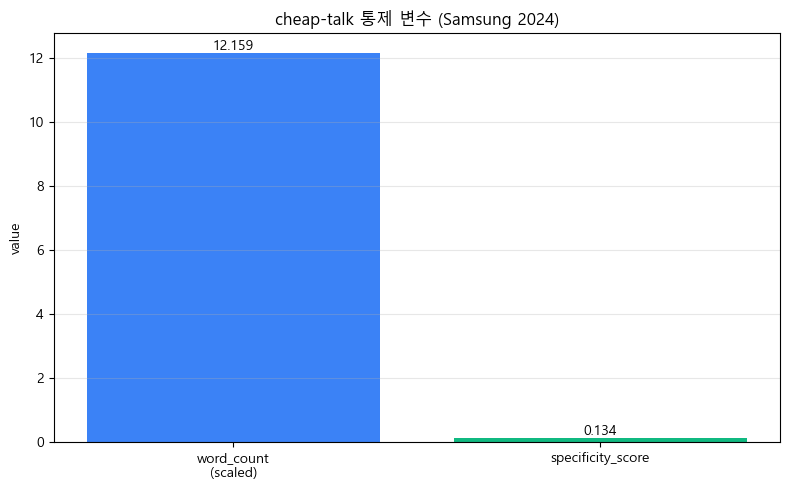

In [5]:
print('📊 alpha 분석 — specificity score = cheap-talk 강화 통제')
print('━' * 60)
print('근거: Bingler/Kraus/Leippold ClimateBert (Finance Research Letters 2022, JBF 2024)')
print('정의: specificity = (숫자/연도/금액 토큰 비율) — 추상 표현 vs 구체 표현 구분')
print()
print(f'본 v1 Samsung 2024:')
print(f'   word_count:        {features["word_count"].iloc[0]}')
print(f'   specificity_score: {features["specificity_score"].iloc[0]:.3f}')
print()
print(f'해석 (N=1이라 비교 불가, 형식만):')
print(f'   - specificity가 높으면 → 정량 표현 위주 → cheap-talk 우려 ↓')
print(f'   - specificity가 낮으면 → 추상 표현 위주 → cheap-talk 우려 ↑')
print()
print(f'v2 batch 후 추가 OLS 모형 (alpha):')
print(f'   esg_grade_num = β0 + β1·seed_tfidf_E + β2·word_count + β3·specificity_score + ε')
print(f'   → β1이 specificity 통제 후에도 유의면 진짜 ESG 측정 가능성 ↑')

# specificity 시각화
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['word_count\n(scaled)', 'specificity_score'],
       [features['word_count'].iloc[0] / 1000, features['specificity_score'].iloc[0]],
       color=['#3b82f6', '#10b981'])
ax.set_title(f'cheap-talk 통제 변수 (Samsung {int(features["fiscal_year"].iloc[0])})')
ax.set_ylabel('value')
for i, v in enumerate([features['word_count'].iloc[0] / 1000, features['specificity_score'].iloc[0]]):
    ax.text(i, v, f'{v:.3f}', ha='center', va='bottom')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'fig_v1_mining_cheaptalk.png', dpi=120)
plt.show()

---
## Step 6 — self-check + v3 batch 후 재실행 안내

### What
풀 사이클 v1 (collection v2 → preprocessing v2 → mining v1) 종합 self-check + 다음 액션.

### Why
가이드 04 §2-1 제출 전 체크리스트 + 5/19 D-Day 직전 상태 정리.


In [6]:
# 풀 사이클 v1 종합 self-check
print('📋 풀 사이클 v1 종합 self-check')
print('━' * 80)

cycle_checks = [
    ('00_ingest_kcgs_v1', '✅', 'kcgs_lineage.csv (381행) + 등급 분포 시각화'),
    ('01_collection_phase2A_v2', '✅', 'Samsung 1건 SUCCESS + dedup + run_id'),
    ('02_preprocessing_v2', '✅', 'esg_features_v2.parquet (1행) + 토큰화 + seed TF-IDF + cosine'),
    ('03_mining_v1', '✅', '본 노트북 + Spearman·t-test·OLS 코드 형식 + specificity alpha'),
]
display(pd.DataFrame(cycle_checks, columns=['노트북', '결과', '산출']))

print('\n\n📋 가이드 04 §2-1 + §3 종합 평가')
print('━' * 80)
final_checks = [
    ('데이터 lineage (식별자)', '✅', 'stock_code → corp_code → rcept_no + viewer'),
    ('데이터 lineage (실패 처리)', '⚠️ 1/381', 'Samsung 1건만 — v3 batch에서 stratified 30건+'),
    ('재현성 (Run All)', '✅', '4 노트북 모두 단독 실행 가능'),
    ('API key 보호', '✅', 'mask_key + KEY_CANDIDATES'),
    ('section II/IV/VI', '✅', 'lxml SECTION-1 14 + section_code'),
    ('seed/expanded 선택 근거', '⚠️', 'seed-only (expanded는 N≥30 필요 — 진단 Step 6)'),
    ('Spearman·t-test', '✅ 코드', 'feature_validity 함수 정의 OK, N=1 NaN'),
    ('모형 선택 근거', '✅', 'OLS baseline + ordered/binary 비교 표'),
    ('cheap-talk 통제', '✅', 'word_count + specificity_score (alpha)'),
    ('연관성 ⭕ 인과 ❌', '✅', '가이드 03 line 276-279 조심스러운 해석 마크다운'),
]
display(pd.DataFrame(final_checks, columns=['항목', '결과', '근거']))

print('\n\n🎯 다음 액션 (D-1, 2026-05-19까지)')
print('━' * 80)
actions = [
    '1. 4 노트북 양쪽 GitHub PR (origin + team)',
    '2. release notes 4개 (00 ingest · 01 collection · 02 preprocessing · 03 mining)',
    '3. 진단 HTML v2 발행 (풀 사이클 v1 완료 상태 반영)',
    '4. v3 batch 설계 — KCGS 등급 stratified 5건 × 6등급 = 30건 sample 선택',
    '5. v3 batch 실행 후 본 노트북 4개 그대로 재실행 → 정상 통계 자동 산출',
]
for a in actions:
    print(f'   {a}')

# regression_results 저장 (N=1이라 placeholder)
results_path = ROOT / 'data' / 'processed' / 'regression_results_v1.csv'
results_df = pd.DataFrame([{
    'model': 'OLS_baseline',
    'feature': 'seed_tfidf_E',
    'control': 'word_count',
    'N': len(features),
    'coefficient': np.nan,
    'p_value': np.nan,
    'note': 'N=1 — v3 batch (N≥30) 후 재실행 필요',
    'timestamp': datetime.now().isoformat(timespec='seconds'),
}])
results_df.to_csv(results_path, index=False, encoding='utf-8-sig')
print(f'\n💾 regression_results_v1.csv 저장 (placeholder)')

📋 풀 사이클 v1 종합 self-check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,노트북,결과,산출
0,00_ingest_kcgs_v1,✅,kcgs_lineage.csv (381행) + 등급 분포 시각화
1,01_collection_phase2A_v2,✅,Samsung 1건 SUCCESS + dedup + run_id
2,02_preprocessing_v2,✅,esg_features_v2.parquet (1행) + 토큰화 + seed TF-I...
3,03_mining_v1,✅,본 노트북 + Spearman·t-test·OLS 코드 형식 + specificit...




📋 가이드 04 §2-1 + §3 종합 평가
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,항목,결과,근거
0,데이터 lineage (식별자),✅,stock_code → corp_code → rcept_no + viewer
1,데이터 lineage (실패 처리),⚠️ 1/381,Samsung 1건만 — v3 batch에서 stratified 30건+
2,재현성 (Run All),✅,4 노트북 모두 단독 실행 가능
3,API key 보호,✅,mask_key + KEY_CANDIDATES
4,section II/IV/VI,✅,lxml SECTION-1 14 + section_code
5,seed/expanded 선택 근거,⚠️,seed-only (expanded는 N≥30 필요 — 진단 Step 6)
6,Spearman·t-test,✅ 코드,"feature_validity 함수 정의 OK, N=1 NaN"
7,모형 선택 근거,✅,OLS baseline + ordered/binary 비교 표
8,cheap-talk 통제,✅,word_count + specificity_score (alpha)
9,연관성 ⭕ 인과 ❌,✅,가이드 03 line 276-279 조심스러운 해석 마크다운




🎯 다음 액션 (D-1, 2026-05-19까지)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   1. 4 노트북 양쪽 GitHub PR (origin + team)
   2. release notes 4개 (00 ingest · 01 collection · 02 preprocessing · 03 mining)
   3. 진단 HTML v2 발행 (풀 사이클 v1 완료 상태 반영)
   4. v3 batch 설계 — KCGS 등급 stratified 5건 × 6등급 = 30건 sample 선택
   5. v3 batch 실행 후 본 노트북 4개 그대로 재실행 → 정상 통계 자동 산출

💾 regression_results_v1.csv 저장 (placeholder)
